# Import Modules

In [2]:
import folium
import random
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd

import branca.colormap as cm
import matplotlib.cm as mplcm
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from fansi_text import Bold
from shapely.geometry import Point

# Get schools via Overpass API

In [3]:
def get_bradford_secondary_schools():
    url = "https://overpass-api.de/api/interpreter"
    headers = {
        "User-Agent": "BradfordSchoolMapper/1.0 (hal@kolb.com)"
    }

    # Bounding box for Bradford
    bbox = "53.71,-2.05,53.96,-1.65"
    # bbox = "53.61,-2.15,54.06,-1.55"
    # bbox = "53.51,-2.25,54.16,-1.45"
    
    query = f"""
    [out:json][timeout:60];
    (
      nwr["amenity"="school"]["isced:level"~"2|3"]({bbox});
      nwr["amenity"="school"]["school:type"="secondary"]({bbox});
    );
    out center;
    """
    
    try:
        response = requests.get(url, params={'data': query}, headers=headers, timeout=60)
        response.raise_for_status()
        data = response.json()
        elements = data.get('elements', [])

        # Process into a list of dictionaries for Pandas
        school_list = []
        for e in elements:
            tags = e.get('tags', {})
            school_list.append({
                "Name": tags.get('name', 'Unnamed School'),
                "URN": tags.get('ref:GB:uass') or tags.get('ref:edubase'),
                "Postcode": tags.get('addr:postcode'),
                "Lat": e.get('lat') or e.get('center', {}).get('lat'),
                "Lon": e.get('lon') or e.get('center', {}).get('lon'),
                "Website": tags.get('website')
            })

        # Create DataFrame
        df = pd.DataFrame(school_list)
        return df

    except Exception as e:
        print(f"Error fetching data: {e}")
        return pd.DataFrame()

# 1. Get the OSM data
df_schools = get_bradford_secondary_schools()

# Export to CSV
if not df_schools.empty:
    df_schools.to_csv("bradford_schools.csv", index=False)
    print("Data exported to bradford_schools.csv")
    print(df_schools.head())

Data exported to bradford_schools.csv
                                                Name     URN  Postcode  \
0                           Hazelbeck Special School  139977  BD16 1EE   
1                             Dixons Trinity Academy  138251   BD5 0BE   
2  Otley Prince Henry's Grammar School Specialist...  137704  LS21 2BB   
3                                    Carlton Bolling  147100   BD3 0DU   
4                                   Bradford Academy  135367   BD4 7QJ   

         Lat       Lon                             Website  
0  53.841401 -1.827540          https://www.hazelbeck.org/  
1  53.786414 -1.761281           https://www.dixonsta.com/  
2  53.912570 -1.694590     https://www.princehenrys.co.uk/  
3  53.802248 -1.738203   https://www.carltonbolling.co.uk/  
4  53.776937 -1.732226  https://www.bradfordacademy.co.uk/  


# Combine school data 

In [25]:
school_data = pd.read_csv("bradford_schools.csv")
# school_perf = pd.read_csv("key-stage-4-performance_2024-25/data/202425_performance_tables_schools_revised.csv")
# school_perf.loc[school_perf["breakdown_topic"] == "Total"][["school_urn", "attainment8_average", "gcse_91_percent"]]

school_perf = pd.read_csv("key-stage-4-performance_2024-25/data/202324_performance_tables_schools_final.csv")
school_perf = school_perf.rename(columns={"avg_att8":"attainment8_average", "t_pupils": "pupil_count"})
school_perf.loc[school_perf["breakdown_topic"] == "Total"][["school_urn", "attainment8_average", "avg_p8score"]]

,school_urn,attainment8_average,avg_p8score
0,100544,6.8,z
10,100001,60.3,z
20,100003,33.3,z
30,137181,46.6,-0.16
40,100049,44.2,-0.2
...,...,...,...
57040,134781,c,z
57050,135940,40.9,-0.36
57060,141993,z,c
57070,112465,z,c


In [27]:
school_data["Attainment 8"] = pd.NA
school_data["Progress 8"] = pd.NA
school_data["Pupil Count"] = pd.NA

for i in range(len(school_data)):
    urn = school_data.loc[i, "URN"]
    att8 = school_perf.loc[(school_perf["school_urn"] == urn) & (school_perf["breakdown_topic"] == "Total")]["attainment8_average"]
    prg8 = school_perf.loc[(school_perf["school_urn"] == urn) & (school_perf["breakdown_topic"] == "Total")]["avg_p8score"]
    pupil_count = school_perf.loc[(school_perf["school_urn"] == urn) & (school_perf["breakdown_topic"] == "Total")]["pupil_count"]
    try:
        att8 = att8.item()
    except ValueError:
        att8 = pd.NA
    try:
        prg8 = prg8.item()
    except ValueError:
        prg8 = pd.NA
    try:
        pupil_count = pupil_count.item()
    except ValueError:
        pupil_count = pd.NA

    try:
        att8 = float(att8)
    except:
        att8 = pd.NA
    try:
        prg8 = float(prg8)
    except:
        prg8 = pd.NA
    try:
        pupil_count = int(pupil_count)
    except:
        pupil_count = pd.NA
    school_data.loc[i, "Attainment 8"] = att8
    school_data.loc[i, "Progress 8"] = prg8
    school_data.loc[i, "Pupil Count"] = pupil_count

school_data

,Name,URN,Postcode,Lat,Lon,Website,Attainment 8,Pupil Count,Progress 8
0,Hazelbeck Special School,139977,BD16 1EE,53.841401,-1.827540,https://www.hazelbeck.org/,<NA>,11,<NA>
1,Dixons Trinity Academy,138251,BD5 0BE,53.786414,-1.761281,https://www.dixonsta.com/,54.7,116,0.72
2,Otley Prince Henry's Grammar School Specialist...,137704,LS21 2BB,53.912570,-1.694590,https://www.princehenrys.co.uk/,53.4,278,0.34
3,Carlton Bolling,147100,BD3 0DU,53.802248,-1.738203,https://www.carltonbolling.co.uk/,43.0,323,0.27
4,Bradford Academy,135367,BD4 7QJ,53.776937,-1.732226,https://www.bradfordacademy.co.uk/,33.1,230,-0.94
...,...,...,...,...,...,...,...,...,...
72,Trinity Academy Halifax,136094,HX2 9TZ,53.753928,-1.877149,https://halifax.trinitymat.org,43.5,318,0.0
73,Green Meadows Academy,148654,LS20 8LS,53.874327,-1.721607,https://greenmeadows.org.uk/,7.3,23,-1.37
74,Fairfield School,107802,WF17 8AS,53.720996,-1.665745,https://www.fairfieldschool.uk/,<NA>,10,<NA>
75,Bronte Girls' Secondary Academy,147067,BD4 7EB,53.785564,-1.745519,https://bga.iexel.org.uk/,51.2,127,0.21


# LSOA data

In [47]:
# Load LSOA Geometry (from: https://geoportal.statistics.gov.uk/datasets/04c65a08ecff4858bffc16e9ca9356f4_0/explore?location=52.846052%2C-2.465415%2C7)

gdf = gpd.read_file("Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BSC_V4_6894679968818356315.geojson")
gdf = gdf[(gdf['LSOA21NM'].str.contains('Bradford'))]# | (gdf['LSOA21NM'].str.contains('Leeds')) | (gdf['LSOA21NM'].str.contains('Calderdale')) | (gdf['LSOA21NM'].str.contains('Kirklees'))].copy() # Calderdale

# Convert to WGS84
if gdf.crs != 'EPSG:4326':
    gdf = gdf.to_crs(epsg=4326)

# Simplify geometry for faster rendering
gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.0001, preserve_topology=True)

In [48]:
# Load house price data (from https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/medianpricepaidbylowerlayersuperoutputareahpssadataset46)
lsoa_house_price = pd.read_csv("C:\\Users\\halko\\Downloads\\hpssadataset46medianpricepaidforresidentialpropertiesbylsoa\\lsoa_house_prices.csv")

# Remove commas and cast to numeric
lsoa_house_price['Price Mar 2023'] = pd.to_numeric(
    lsoa_house_price['Price Mar 2023'].str.replace(',', ''), 
    errors='coerce'
)

In [49]:
# Load imd data (from https://communitiesopendata-communities.hub.arcgis.com/datasets/0fddc254c1184386bbeed27ed49bbd03_0/about)
lsoa_imd = pd.read_csv("LSOA_IMD2025_WGS84.csv")
lsoa_imd = lsoa_imd[["LSOA Code", "IMD Decile"]]

In [50]:
# Merge price data onto the GeoDataFrame
merged_gdf = gdf.merge(
    lsoa_house_price, 
    left_on='LSOA21CD', 
    right_on='LSOA code', 
    how='left'
)

# Merge IMD data onto the GeoDataFrame
merged_gdf = merged_gdf.merge(
    lsoa_imd, 
    left_on='LSOA21CD', 
    right_on='LSOA Code', 
    how='left'
)

In [51]:
colour_feature = "IMD Decile"

# 4. Create Color Scale
# Filter out NaNs for the colormap calculation
valid_prices = merged_gdf[colour_feature].dropna()
colormap = cm.LinearColormap(
    colors=["yellow", "orange", "red"],#["#090C50", '#4297AD', '#D2E49D'], #["red", "orange", "green"],
    vmin=valid_prices.min(),
    vmax=valid_prices.quantile(0.95) # Cap at 95th percentile to maintain color contrast
)

# 5. Initialize the Map
m = folium.Map(location=[53.79, -1.75], zoom_start=11, tiles='CartoDB positron')

# 6. Add LSOA Polygons with Dynamic Styling

folium.GeoJson(
    merged_gdf,
    name='Bradford House Prices',
    style_function=lambda feature: {
        'fillColor': colormap(feature['properties'][colour_feature]) 
                     if feature['properties'][colour_feature] is not None else '#808080',
        'color': 'white',
        'weight': 1,
        'fillOpacity': 0.4,
    },
    # highlight_function=lambda feature: {
    #     'weight': 3,
    #     'fillOpacity': 0.6,
    # },
    # tooltip=folium.GeoJsonTooltip(
    #     fields=['LSOA21NM', 'LSOA21CD', colour_feature],
    #     aliases=['LSOA Name:', 'Code:', 'Median Price (£):'],
    #     localize=True
    # )
).add_to(m)

# 7. Add the Colormap Legend
colormap.caption = colour_feature #'Median House Price (March 2023)'
colormap.add_to(m)

### Plot schools

In [52]:
# Define the range for color scale
vmin = school_data["Attainment 8"].min()
vmax = school_data["Attainment 8"].max()

# Create a normalization object and the colormap
norm = colors.Normalize(vmin=vmin, vmax=vmax)
colormap_schools = mplcm.viridis  # You can also use 'plasma', 'magma', or 'inferno'

In [53]:
def get_att8_color(score):
    if pd.isna(score):
        return 'gray'
    
    # Map the score to a 0.0 - 1.0 range
    normalized_score = norm(score)
    
    # Get the RGBA color from the colormap
    rgba = colormap_schools(normalized_score)
    
    # Convert RGBA to Hex format (which Folium prefers)
    return colors.rgb2hex(rgba)

In [54]:
for i in range(len(school_data)):
    school = school_data.loc[i]
    name = school["Name"]
    lat = school["Lat"]
    lon = school["Lon"]
    att8 = school["Attainment 8"]
    prg8 = school["Progress 8"]
    pup_count = school["Pupil Count"]
    
    # 3. Scale the pupil count for the radius 
    # (e.g., 1000 pupils / 100 = 10 pixel radius)
    if pd.isna(pup_count) or pup_count == 0:
        marker_radius = 5 # Default fallback size
    else:
        marker_radius = int(pup_count) / 20

    # 4. Get the color for this specific school
    marker_color = get_att8_color(att8)

    # 5. Add the CircleMarker to the map
    folium.CircleMarker(
        location=[lat, lon],
        radius=marker_radius,
        popup=folium.Popup(name, max_width=300),
        tooltip=f"{name} | Att8: {att8} | Prg8: {prg8} | Pupils: {pup_count}",
        color=marker_color,         # Outline color
        weight=1,                   # Outline thickness
        fill=True,
        fill_color=marker_color,    # Inside color
        fill_opacity=1.0            # Slight transparency to see overlapping schools
    ).add_to(m)

In [55]:
# 9. Save and View
m.save('bradford_house_prices_schools.html')

# Navigation via OSRM with local host using docker image

https://github.com/project-osrm/osrm-backend/pkgs/container/osrm-backend

```
# Extract the graph for car directions
docker run -t -v "${PWD}:/data" osrm/osrm-backend osrm-extract -p /opt/car.lua /data/west-yorkshire-260414.osm.pbf
docker run -t -v "${PWD}:/data" osrm/osrm-backend osrm-extract -p /opt/bicycle.lua /data/west-yorkshire-bike.osm.pbf
docker run -t -v "${PWD}:/data" osrm/osrm-backend osrm-extract -p /opt/foot.lua /data/west-yorkshire-foot.osm.pbf

# Partition and customize the graph for routing
docker run -t -v "${PWD}:/data" osrm/osrm-backend osrm-partition /data/west-yorkshire-260414.osrm
docker run -t -v "${PWD}:/data" osrm/osrm-backend osrm-customize /data/west-yorkshire-260414.osrm

# Start local server
docker run -t -i -p 5000:5000 -v "${PWD}:/data" osrm/osrm-backend osrm-routed --algorithm mld /data/west-yorkshire-260414.osrm

# Walking (foot) version
docker run -t -i -p 5001:5000 -v "${PWD}:/data" osrm/osrm-backend osrm-routed --algorithm mld /data/west-yorkshire-foot.osrm

# Cycling version
docker run -t -i -p 5002:5000 -v "${PWD}:/data" osrm/osrm-backend osrm-routed --algorithm mld /data/west-yorkshire-bike.osrm
```

- Take a given LSOA
- For that LSOA get all OAs within it
- Get population of each OA
- Select a sample OA weighted by population
- Within that OA select a random location contained within the polygon (maybe there's a better way ?)
- For that point use OSRM to calculate the duration of walking, cycling and driving between the point and each school
- Repeat sampling to get a distribution of journey times accross the LSOA

## Load data

In [11]:
# Load OA population data (from https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/censusoutputareapopulationestimatessupportinginformation)
oa_population = pd.read_csv("OutputArea_Population_21.csv")

oa_population['Population'] = pd.to_numeric(
    oa_population['Population'].astype(str).str.replace(',', ''), 
    errors='coerce'
)

In [12]:
# Load geometry data (from https://www.data.gov.uk/dataset/4d4e021d-fe98-4a0e-88e2-3ead84538537/output-areas-december-2021-boundaries-ew-bgc-v21)
oa_gdf = gpd.read_file("Output_Areas_2021_EW_BGC_V2.geojson")
oa_gdf = oa_gdf.to_crs(epsg=4326) # Convert geometry data to latitude and longitude

## Select LSOA

In [13]:
chosen_LSOA = "E01010572"

## Random point selection

In [14]:
# Simple rejection sampling for a point in an OA polygon
def random_point_in_polygon(polygon):
    minx, miny, maxx, maxy = polygon.bounds

    while True:
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        point = Point(x, y)
        if polygon.contains(point):
            return point

### Test random point selection

In [15]:
# Locate all OAs within chosen LSOA
chosen_oas = oa_population.loc[oa_population["LSOA21CD"] == chosen_LSOA]

# Select OA within LSOA weighted by population
oa_pick = random.choices(list(chosen_oas["OA21CD"]), weights=chosen_oas["Population"], k=1)[0]

<Axes: >

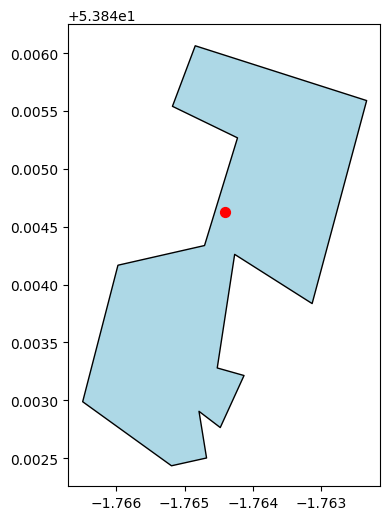

In [16]:
# Get the OA's polygon and pick a point in it
poly = oa_gdf.loc[oa_gdf["OA21CD"] == oa_pick, "geometry"]
random_point = random_point_in_polygon(poly.item())

# Plot OA and point
point_gdf = gpd.GeoSeries([random_point], crs=oa_gdf.crs)
fig, ax = plt.subplots(figsize=(6, 6))
poly.plot(ax=ax, edgecolor="black", facecolor="lightblue")
point_gdf.plot(ax=ax, color="red", markersize=50)

## Sample points and calculate mean travel time for each method

In [17]:
def sample_start_point(LSOA:str) -> str:
    # Locate all OAs within chosen LSOA
    chosen_oas = oa_population.loc[oa_population["LSOA21CD"] == chosen_LSOA]
    # Select OA within LSOA weighted by population
    oa_pick = random.choices(list(chosen_oas["OA21CD"]), weights=chosen_oas["Population"], k=1)[0]

    # Pick random starting point in output area
    poly = oa_gdf.loc[oa_gdf["OA21CD"] == oa_pick, "geometry"].item()
    random_point = random_point_in_polygon(poly)
    lat = random_point.y
    long = random_point.x
    start = f"{long},{lat}"

    return start

In [18]:
# Use local OSRM server to quickly calculate journey times
def time_journey(origin, dest, travel_type="driving"):
    port_map = {"driving": 0, "foot": 1, "bike": 2}
    
    # Hit local OSRM server
    url = f"http://127.0.0.1:500{port_map[travel_type]}/route/v1/{travel_type}/{origin};{dest}?overview=false"
    response = requests.get(url).json()

    journey_time_seconds = response['routes'][0]['duration']
    return journey_time_seconds

In [ ]:
num_samples = 200

print(f"Origin: {chosen_LSOA}")
for i in range(len(school_data)):
    name = school_data.loc[i, "Name"]
    lat = school_data.loc[i, "Lat"]
    lon = school_data.loc[i, "Lon"]
    dest = f"{lon},{lat}"

    print(f"    {Bold(name.upper())}")

    for mode in ["foot", "bike", "driving"]:
        times_list = []
        for j in range(num_samples):
            start = sample_start_point(chosen_LSOA)
            times_list.append(time_journey(start, dest, travel_type=mode))
        jour_time = np.array(times_list).mean()
        sd = np.array(times_list).std()

        print(f"        {mode}: {round(jour_time//60):02d}m{round(jour_time%60):02d}s, std: {sd:.1f}s")

    if i == 3: break # Short output for testing 

<Axes: >

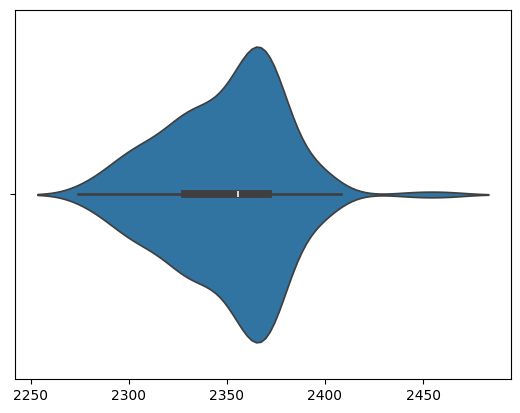

In [ ]:
sns.violinplot(x=times_list)

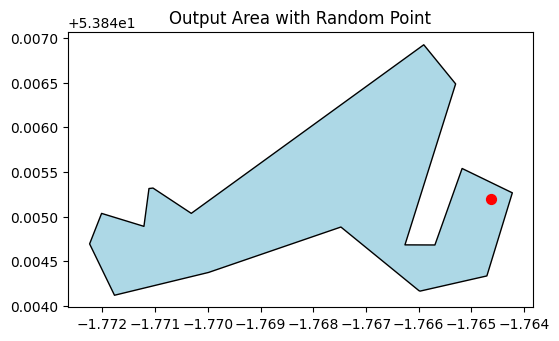